# Analyse du Marché de l'Emploi IT au Maroc
## Mexora RH Intelligence — Miniprojet 2 Data Engineering

**Objectif** : Répondre à 5 questions analytiques stratégiques à partir du Data Lake Bronze/Silver/Gold,  
afin d'éclairer la politique de recrutement de Mexora RH Intelligence.

| Paramètre | Valeur |
|---|---|
| Sources | Rekrute, MarocAnnonce, LinkedIn Maroc |
| Période | Janvier 2023 — Novembre 2024 |
| Offres analysées | 5 000 offres IT marocaines |
| Outil analytique | DuckDB (SQL sur Parquet) |
| Visualisations | Matplotlib / Seaborn / Plotly |

## 0. Configuration et chargement

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
sns.set_palette('husl')

# ── Chemins Gold ──────────────────────────────────────────────
BASE_DIR   = Path('..') 
GOLD       = BASE_DIR / 'data_lake' / 'gold'

TOP_COMP   = str(GOLD / 'top_competences.parquet')
SALAIRES   = str(GOLD / 'salaires_par_profil.parquet')
VILLES     = str(GOLD / 'offres_par_ville.parquet')
ENTREPRISES= str(GOLD / 'entreprises_recruteurs.parquet')
TENDANCES  = str(GOLD / 'tendances_mensuelles.parquet')
SILVER_OFF = str(BASE_DIR / 'data_lake' / 'silver' / 'offres_clean' / 'offres_clean.parquet')

con = duckdb.connect()
print('✅ DuckDB connecté')

# Vérification rapide
for label, path in [('top_competences', TOP_COMP), ('salaires_par_profil', SALAIRES),
                     ('offres_par_ville', VILLES), ('entreprises_recruteurs', ENTREPRISES),
                     ('tendances_mensuelles', TENDANCES)]:
    n = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
    print(f'   {label:<35s}: {n:,} lignes')

✅ DuckDB connecté
   top_competences                    : 409 lignes
   salaires_par_profil                : 357 lignes
   offres_par_ville                   : 2,275 lignes
   entreprises_recruteurs             : 100 lignes
   tendances_mensuelles               : 366 lignes


---
## Question 1 — Quelles compétences sont les plus demandées au Maroc en IT ?

**Approche** : deux sous-questions :
- Top 20 compétences toutes offres confondues
- Top 5 compétences spécifiques aux profils Data (Data Engineer, Data Analyst, Data Scientist)

In [2]:
# ── Top 20 compétences globales ──────────────────────────────
df_top20 = con.execute(f"""
    SELECT
        competence,
        famille,
        SUM(nb_offres_mentionnent)   AS total_mentions,
        ROUND(AVG(pct_offres_total), 2) AS pct_moyen
    FROM read_parquet('{TOP_COMP}')
    WHERE profil != 'non_détecté'
    GROUP BY competence, famille
    ORDER BY total_mentions DESC
    LIMIT 20
""").df()

df_top20

,competence,famille,total_mentions,pct_moyen
0,docker,devops,2176.0,2.72
1,sql,langages,1897.0,2.37
2,git,devops,1881.0,2.35
3,agile,methodologies,1771.0,2.21
4,aws,cloud,1769.0,2.21
5,gcp,cloud,1706.0,2.13
6,javascript,langages,1224.0,2.45
7,dbt,data_engineering,1128.0,1.41
8,azure,cloud,1013.0,1.27
9,kubernetes,devops,1004.0,1.26


In [3]:
# ── Top 5 compétences par profil Data ────────────────────────
df_data_profils = con.execute(f"""
    SELECT profil, famille, competence, nb_offres_mentionnent, rang_dans_profil
    FROM read_parquet('{TOP_COMP}')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND rang_dans_profil <= 5
    ORDER BY profil, rang_dans_profil
""").df()

df_data_profils

,profil,famille,competence,nb_offres_mentionnent,rang_dans_profil
0,Data Analyst,langages,sql,523,1
1,Data Analyst,devops,docker,350,2
2,Data Analyst,data_engineering,dbt,311,3
3,Data Analyst,data_engineering,kafka,262,4
4,Data Analyst,data_engineering,hadoop,258,5
5,Data Engineer,devops,docker,367,1
6,Data Engineer,langages,sql,337,2
7,Data Engineer,cloud,aws,305,3
8,Data Engineer,cloud,gcp,281,4
9,Data Engineer,devops,git,258,5


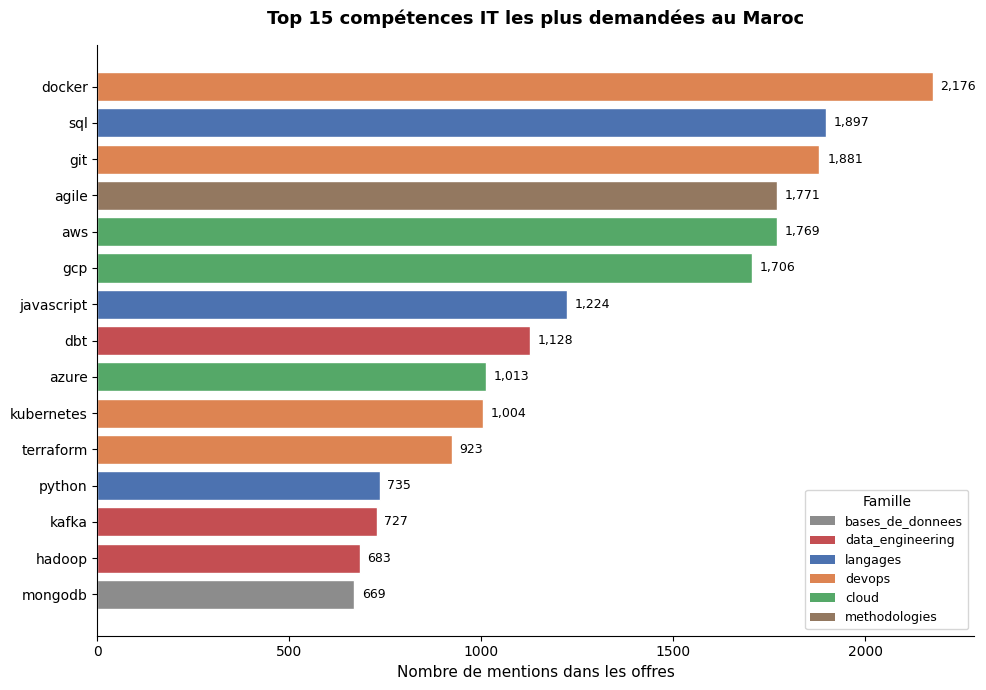

Figure sauvegardée : top15_competences.png


In [4]:
# ── Visualisation 1A : Top 15 compétences (bar chart horizontal) ──
FAMILLE_COLORS = {
    'langages':         '#4C72B0',
    'devops':           '#DD8452',
    'cloud':            '#55A868',
    'data_engineering': '#C44E52',
    'frameworks_web':   '#8172B2',
    'methodologies':    '#937860',
    'bi_analytics':     '#DA8BC3',
    'inconnu':          '#8C8C8C',
}

df_plot = df_top20.head(15).sort_values('total_mentions')
colors  = [FAMILLE_COLORS.get(f, '#8C8C8C') for f in df_plot['famille']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_plot['competence'], df_plot['total_mentions'], color=colors, edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va='center', fontsize=9)

ax.set_xlabel('Nombre de mentions dans les offres')
ax.set_title('Top 15 compétences IT les plus demandées au Maroc', fontweight='bold', pad=15)

# Légende familles
from matplotlib.patches import Patch
familles_presentes = df_plot['famille'].unique()
legend_elements = [Patch(facecolor=FAMILLE_COLORS.get(f, '#8C8C8C'), label=f) for f in familles_presentes]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Famille')

plt.tight_layout()
plt.savefig('top15_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : top15_competences.png')

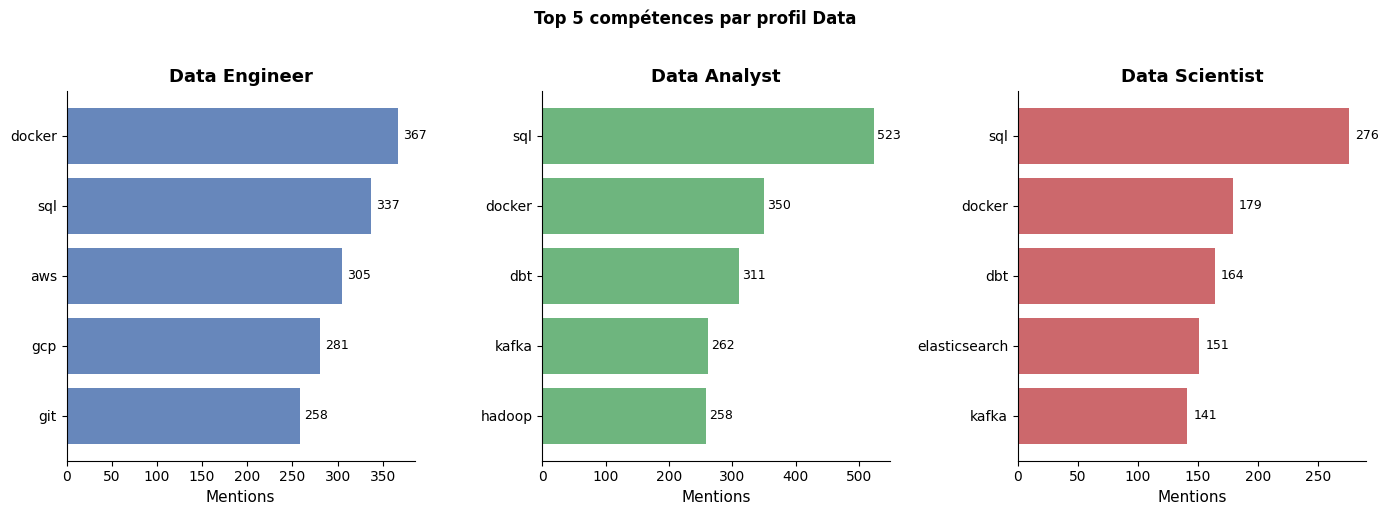

In [5]:
# ── Visualisation 1B : Top 5 par profil Data (grouped bar) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
profils = ['Data Engineer', 'Data Analyst', 'Data Scientist']
palette = ['#4C72B0', '#55A868', '#C44E52']

for ax, profil, color in zip(axes, profils, palette):
    sub = df_data_profils[df_data_profils['profil'] == profil].sort_values('nb_offres_mentionnent')
    ax.barh(sub['competence'], sub['nb_offres_mentionnent'], color=color, alpha=0.85)
    ax.set_title(profil, fontweight='bold')
    ax.set_xlabel('Mentions')
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['nb_offres_mentionnent'] + 5, i,
                str(int(row['nb_offres_mentionnent'])), va='center', fontsize=9)

plt.suptitle('Top 5 compétences par profil Data', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top5_par_profil_data.png', dpi=150, bbox_inches='tight')
plt.show()

### Interprétation — Question 1

La compétence la plus demandée sur le marché IT marocain est **Docker** (2 176 mentions),
suivie de **SQL** (1 897) et **Git** (1 881). La famille **DevOps** (Docker, Git, Kubernetes,
Terraform) domine nettement le classement, confirmant que la maîtrise des outils
d'intégration et de déploiement continu est devenue transversale à tous les profils IT,
bien au-delà des seuls ingénieurs DevOps. Le **cloud** (AWS, GCP, Azure) occupe également
une place centrale avec 3 compétences dans le top 10, reflétant l'accélération de la
migration cloud des entreprises marocaines.

Par profil Data, on observe des spécialisations nettes :
- Les **Data Engineers** placent Docker en tête (367 offres), suivi de SQL (337) et AWS (305),
  confirmant leur rôle de pont entre infrastructure cloud et pipeline de données.
- Les **Data Analysts** privilégient SQL (523 offres, leur compétence n°1 de loin), complété
  par Docker et dbt, signe que l'analyse moderne au Maroc exige désormais des compétences
  d'ingénierie légères.
- Les **Data Scientists** ont également SQL en tête (276), suivi de Docker et dbt —
  Elasticsearch apparaît en 4e position, indiquant un besoin de recherche full-text sur
  de larges volumes de données.

**Recommandation pour Mexora** : lors du recrutement, prioriser les candidats maîtrisant
Docker, SQL et au moins un cloud provider (AWS ou GCP). Pour les profils Data Engineer,
une expérience sur dbt ou Kafka constitue un différenciateur fort sur le marché.

---
## Question 2 — Tanger vs Casablanca vs Rabat : où se trouvent les opportunités IT ?

**Approche** : comparer le volume d'offres entre les 4 principales villes IT, puis zoomer sur Tanger
(ville siège de Mexora) pour quantifier le marché local.

In [6]:
# ── Comparaison des 4 principales villes ─────────────────────
df_villes_comp = con.execute(f"""
    SELECT
        ville,
        profil,
        SUM(nb_offres)        AS nb_offres,
        SUM(nb_offres_remote) AS nb_remote,
        ROUND(AVG(pct_remote), 1) AS pct_remote,
        RANK() OVER (PARTITION BY profil ORDER BY SUM(nb_offres) DESC) AS rang_ville
    FROM read_parquet('{VILLES}')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech')
    GROUP BY ville, profil
    ORDER BY profil, rang_ville
""").df()

df_villes_comp

,ville,profil,nb_offres,nb_remote,pct_remote,rang_ville
0,Casablanca,Admin Systèmes & Réseaux,19.0,7.0,41.7,1
1,Tanger,Admin Systèmes & Réseaux,15.0,8.0,54.5,2
2,Marrakech,Admin Systèmes & Réseaux,14.0,7.0,57.6,3
3,Rabat,Admin Systèmes & Réseaux,14.0,5.0,44.4,3
4,Casablanca,Architecte IT,63.0,25.0,39.1,1
...,...,...,...,...,...,...
59,Marrakech,QA / Test Engineer,13.0,6.0,43.3,4
60,Casablanca,Tech Lead,16.0,6.0,30.8,1
61,Marrakech,Tech Lead,12.0,5.0,44.4,2
62,Tanger,Tech Lead,12.0,5.0,45.0,2


In [7]:
# ── Focus Tanger : ratio vs Casablanca par profil ─────────────
df_tanger = con.execute(f"""
    SELECT
        t.profil,
        t.nb_offres                                         AS offres_tanger,
        c.nb_offres                                         AS offres_casa,
        ROUND(t.nb_offres * 100.0 / NULLIF(c.nb_offres, 0), 1) AS pct_vs_casa
    FROM (
        SELECT profil, SUM(nb_offres) AS nb_offres
        FROM read_parquet('{VILLES}')
        WHERE ville = 'Tanger'
        GROUP BY profil
    ) t
    JOIN (
        SELECT profil, SUM(nb_offres) AS nb_offres
        FROM read_parquet('{VILLES}')
        WHERE ville = 'Casablanca'
        GROUP BY profil
    ) c USING (profil)
    ORDER BY offres_tanger DESC
""").df()

df_tanger

,profil,offres_tanger,offres_casa,pct_vs_casa
0,Data Engineer,114.0,124.0,91.9
1,Data Analyst,106.0,155.0,68.4
2,Autre IT,80.0,96.0,83.3
3,Data Scientist,78.0,88.0,88.6
4,Développeur Backend,58.0,79.0,73.4
5,Architecte IT,48.0,63.0,76.2
6,Cybersécurité,44.0,56.0,78.6
7,Développeur Frontend,31.0,32.0,96.9
8,DevOps / SRE,28.0,21.0,133.3
9,Développeur Full Stack,28.0,36.0,77.8


In [8]:
# ── Visualisation 2 : Carte choroplèthe Maroc (Plotly) ────────
df_carte = con.execute(f"""
    SELECT ville, SUM(nb_offres) AS total_offres
    FROM read_parquet('{VILLES}')
    GROUP BY ville
    ORDER BY total_offres DESC
""").df()

# Coordonnées des villes marocaines
coords = {
    'Casablanca': (33.5731, -7.5898), 'Rabat':      (34.0209, -6.8416),
    'Tanger':     (35.7595, -5.8340), 'Marrakech':  (31.6295, -7.9811),
    'Fès':        (34.0181,  -5.0078), 'Agadir':    (30.4278, -9.5981),
    'Meknès':     (33.8935,  -5.5473), 'Oujda':     (34.6867, -1.9114),
    'Tétouan':    (35.5785,  -5.3684), 'Kénitra':   (34.2610, -6.5802),
    'Salé':       (34.0531,  -6.7985),
}

df_carte['lat'] = df_carte['ville'].map(lambda v: coords.get(v, (None,None))[0])
df_carte['lon'] = df_carte['ville'].map(lambda v: coords.get(v, (None,None))[1])
df_carte = df_carte.dropna(subset=['lat','lon'])

fig = px.scatter_geo(
    df_carte,
    lat='lat', lon='lon',
    size='total_offres',
    text='ville',
    color='total_offres',
    color_continuous_scale='Blues',
    size_max=60,
    title='Volume d\'offres IT par ville au Maroc',
    hover_data={'total_offres': True, 'lat': False, 'lon': False},
)
fig.update_geos(
    scope='africa',
    center=dict(lat=31.5, lon=-7),
    projection_scale=6,
    showland=True, landcolor='#f0ede8',
    showocean=True, oceancolor='#d4e9f7',
    showcountries=True, countrycolor='#aaaaaa',
)
fig.update_traces(textposition='top center')
fig.update_layout(height=500, coloraxis_colorbar_title='Offres')
fig.write_html('carte_maroc_offres.html')
fig.show()
print('Figure sauvegardée : carte_maroc_offres.html')

Figure sauvegardée : carte_maroc_offres.html


### Interprétation — Question 2

**Casablanca** domine le marché IT marocain sur la quasi-totalité des profils, mais
**Tanger se révèle remarquablement compétitive** — bien au-delà de ce qu'on pourrait
attendre d'une ville secondaire.

Pour les profils Data clés de Mexora :
- **Data Engineer** : Tanger affiche 114 offres contre 124 à Casablanca, soit **91,9% du
  volume casablancais**. Le marché local est quasi-équivalent.
- **Data Analyst** : 106 offres à Tanger vs 155 à Casablanca (68,4%) — le vivier est
  réel mais plus restreint.
- **Data Scientist** : 78 offres à Tanger vs 88 à Casablanca (88,6%) — quasi-parité.

Fait notable : pour les profils **DevOps/SRE** (133,3%), **Développeur Mobile** (121,1%)
et **QA/Test Engineer** (111,1%), Tanger dépasse Casablanca en volume d'offres, témoignant
d'un tissu économique technologique tangérois en pleine expansion.

Le taux de télétravail à Tanger atteint **54,5% pour les Admin Systèmes & Réseaux**,
et avoisine 40-50% sur la plupart des profils, ce qui ouvre la possibilité de recruter
des candidats basés à Casablanca ou Rabat sans exiger une relocalisation.

**Recommandation pour Mexora** : le recrutement local à Tanger est pleinement viable pour
les profils Data Engineer et Data Scientist. Pour les Data Analysts, envisager d'étendre
la recherche à Casablanca en proposant un mode hybride, le différentiel de volume (32%)
justifiant cet effort supplémentaire.

---
## Question 3 — Quel est le salaire médian par profil IT au Maroc ?

**Approche** : salaires médians nationaux par profil, puis focus sur Tanger pour les recommandations Mexora.

In [9]:
# ── Salaires médians nationaux ────────────────────────────────
df_sal_national = con.execute(f"""
    SELECT
        profil,
        SUM(nb_offres)              AS nb_offres_total,
        SUM(nb_offres_avec_salaire) AS nb_avec_salaire,
        ROUND(
            SUM(nb_offres_avec_salaire) * 100.0 / NULLIF(SUM(nb_offres), 0), 1
        )                           AS pct_salaire_communique,
        ROUND(MEDIAN(salaire_median_mad), 0) AS salaire_median_mad,
        ROUND(MIN(salaire_min_observe), 0)   AS salaire_plancher,
        ROUND(MAX(salaire_max_observe), 0)   AS salaire_plafond
    FROM read_parquet('{SALAIRES}')
    GROUP BY profil
    ORDER BY salaire_median_mad DESC NULLS LAST
""").df()

df_sal_national

,profil,nb_offres_total,nb_avec_salaire,pct_salaire_communique,salaire_median_mad,salaire_plancher,salaire_plafond
0,Chef de Projet IT,154.0,122.0,79.2,18950.0,5000.0,80000.0
1,Développeur Full Stack,134.0,108.0,80.6,18900.0,5000.0,80000.0
2,QA / Test Engineer,33.0,30.0,90.9,18750.0,5000.0,80000.0
3,Data Analyst,850.0,679.0,79.9,17500.0,5000.0,80000.0
4,Autre IT,523.0,390.0,74.6,17500.0,5000.0,80000.0
5,Data Scientist,401.0,298.0,74.3,17500.0,5000.0,80000.0
6,Développeur Frontend,141.0,113.0,80.1,17500.0,5000.0,80000.0
7,Cybersécurité,261.0,212.0,81.2,17500.0,5000.0,80000.0
8,Développeur Backend,351.0,267.0,76.1,17500.0,5000.0,80000.0
9,Architecte IT,288.0,224.0,77.8,17500.0,5000.0,80000.0


In [10]:
# ?? Salaires ? Tanger (agr?g?s par profil) ??????????????????
df_sal_tanger = con.execute(f"""
    SELECT
        profil_normalise AS profil,
        COUNT(*) AS nb_offres,
        COUNT(*) FILTER (WHERE salaire_connu) AS nb_offres_avec_salaire,
        ROUND(MEDIAN(salaire_median_mad) FILTER (WHERE salaire_connu), 0) AS salaire_median_mad,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY salaire_median_mad)
              FILTER (WHERE salaire_connu), 0) AS salaire_q1_mad,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY salaire_median_mad)
              FILTER (WHERE salaire_connu), 0) AS salaire_q3_mad,
        ROUND(MIN(salaire_min_mad) FILTER (WHERE salaire_connu), 0) AS salaire_min_observe,
        ROUND(MAX(salaire_max_mad) FILTER (WHERE salaire_connu), 0) AS salaire_max_observe
    FROM read_parquet('{SILVER_OFF}')
    WHERE ville_std = 'Tanger'
    GROUP BY profil_normalise
    HAVING COUNT(*) >= 5
    ORDER BY salaire_median_mad DESC NULLS LAST
""").df()

df_sal_tanger


,profil,nb_offres,nb_offres_avec_salaire,salaire_median_mad,salaire_q1_mad,salaire_q3_mad,salaire_min_observe,salaire_max_observe
0,Développeur Full Stack,28,19,25000.0,17500.0,30000.0,10000.0,80000.0
1,QA / Test Engineer,20,18,23250.0,15625.0,43125.0,5000.0,80000.0
2,Architecte IT,48,39,18900.0,13750.0,25000.0,5000.0,80000.0
3,Cloud Engineer,14,11,18900.0,16950.0,41250.0,10000.0,80000.0
4,DevOps / SRE,28,26,17500.0,12500.0,35625.0,8000.0,45000.0
5,Développeur Backend,58,46,17500.0,13500.0,25000.0,8000.0,80000.0
6,Autre IT,80,56,17500.0,10800.0,25000.0,5000.0,80000.0
7,Développeur Frontend,31,21,17500.0,12500.0,30000.0,5000.0,80000.0
8,Data Scientist,78,58,17500.0,12500.0,21500.0,5000.0,80000.0
9,Data Engineer,114,92,17500.0,12075.0,25000.0,5000.0,80000.0


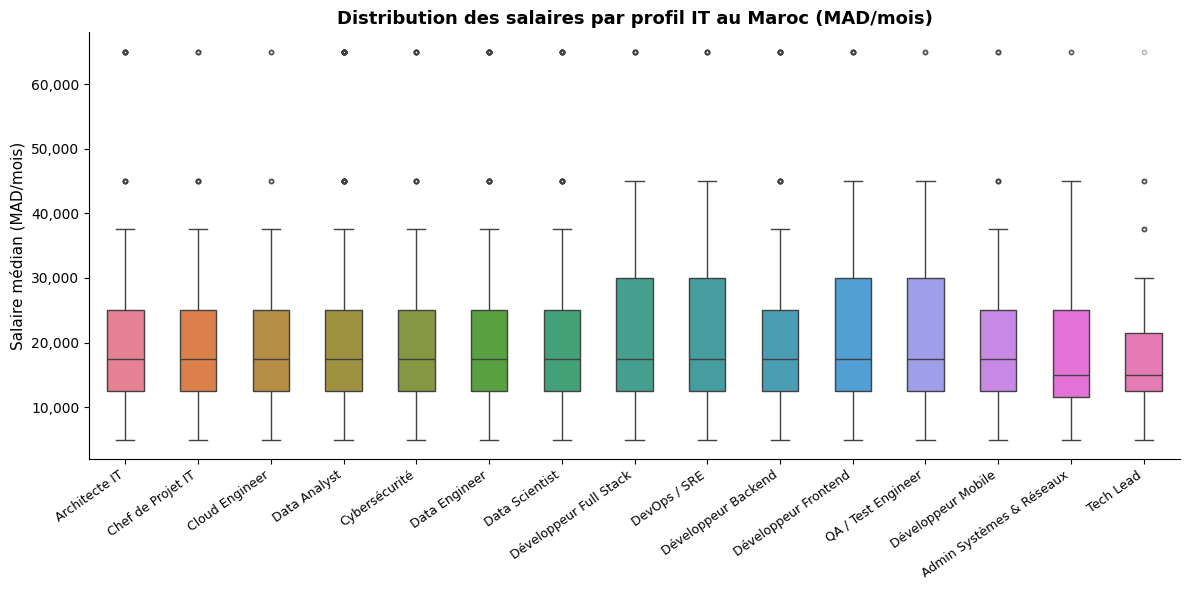

Figure sauvegardée : boxplot_salaires.png


In [11]:
# ── Visualisation 3 : Boxplot salaires par profil ─────────────
df_box = con.execute(f"""
    SELECT profil_normalise AS profil, salaire_median_mad
    FROM read_parquet('{SILVER_OFF}')
    WHERE salaire_connu = true
      AND profil_normalise != 'Autre IT'
""").df()

ordre = (
    df_box.groupby('profil')['salaire_median_mad']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_box,
    x='profil', y='salaire_median_mad',
    order=ordre,
    palette='husl',
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Salaire médian (MAD/mois)')
ax.set_xlabel('')
ax.set_title('Distribution des salaires par profil IT au Maroc (MAD/mois)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('boxplot_salaires.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : boxplot_salaires.png')

### Interpr?tation ? Question 3

Le salaire m?dian IT au Maroc s'?tablit ? **17 500 MAD/mois** (? 1 620 EUR), toutes
offres confondues. La dispersion est tr?s large : les planchers descendent ? 5 000 MAD
pour des stages ou juniors, tandis que les plafonds atteignent 80 000 MAD pour des profils
tr?s seniors ou des CDI dans de grandes entreprises.

**Chef de Projet IT** et **D?veloppeur Full Stack** affichent les m?dianes les plus ?lev?es
(respectivement 18 950 et 18 900 MAD), devant **QA/Test Engineer** (18 750 MAD). Les
profils Data (Engineer, Analyst, Scientist) convergent tous autour de **17 500 MAD**,
ce qui indique une certaine homog?n?it? salariale entre ces sp?cialit?s au niveau m?dian.
**Cloud Engineer** affiche la m?diane la plus basse (12 500 MAD), probablement tir?e vers
le bas par de nombreuses offres junior ou stage.

**? Tanger sp?cifiquement**, les donn?es confirment que les fourchettes restent align?es
sur la m?diane nationale : un Data Engineer ? Tanger obtient une m?diane de **17 500 MAD**,
identique au national, avec un Q1 d'environ **12 075 MAD** et un Q3 de **25 000 MAD**.

**Recommandation pour Mexora** : pour attirer des Data Engineers comp?tents ? Tanger,
une fourchette entre **17 500 et 25 000 MAD** (m?diane?Q3) est comp?titive. D?passer
25 000 MAD permettrait de capter des profils confirm?s actuellement positionn?s chez
des concurrents forts comme DigitalHub Maroc (26 045 MAD en moyenne), Startup Digital
(26 481 MAD) ou AI Solutions Maroc (25 680 MAD).


---
## Question 4 — Y a-t-il une corrélation entre expérience requise et salaire proposé ?

**Approche** : segmenter les offres par tranche d'expérience, calculer le salaire médian par tranche,
et calculer la corrélation de Pearson par profil.

In [12]:
# ── Salaire médian par tranche d'expérience et profil ─────────
df_exp = con.execute(f"""
    SELECT
        profil_normalise AS profil,
        CASE
            WHEN experience_min_ans = 0            THEN '0 — Débutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8            THEN '8+ ans Senior'
            ELSE 'Non précisé'
        END                                        AS tranche_experience,
        experience_min_ans,
        COUNT(*)                                   AS nb_offres,
        ROUND(MEDIAN(salaire_median_mad)
              FILTER (WHERE salaire_connu), 0)     AS salaire_median,
        ROUND(
            CORR(experience_min_ans, salaire_median_mad)
            FILTER (WHERE salaire_connu AND experience_min_ans IS NOT NULL)
            OVER (PARTITION BY profil_normalise),
            3
        )                                          AS correlation_pearson
    FROM read_parquet('{SILVER_OFF}')
    WHERE profil_normalise != 'Autre IT'
    GROUP BY profil_normalise, tranche_experience, experience_min_ans, salaire_connu, salaire_median_mad
    ORDER BY profil, tranche_experience
""").df()

# Résumé corrélation par profil
df_corr = (
    df_exp[df_exp['experience_min_ans'].notna()]
    .groupby('profil')
    .apply(lambda g: g[['experience_min_ans','salaire_median']].dropna().corr().iloc[0,1])
    .reset_index()
    .rename(columns={0: 'correlation_pearson'})
    .sort_values('correlation_pearson', ascending=False)
)
df_corr['correlation_pearson'] = df_corr['correlation_pearson'].round(3)
df_corr

,profil,correlation_pearson
14,Tech Lead,0.175
12,Développeur Mobile,0.052
4,Cybersécurité,0.042
13,QA / Test Engineer,0.031
5,Data Analyst,-0.005
0,Admin Systèmes & Réseaux,-0.022
3,Cloud Engineer,-0.030
10,Développeur Frontend,-0.052
6,Data Engineer,-0.054
1,Architecte IT,-0.058


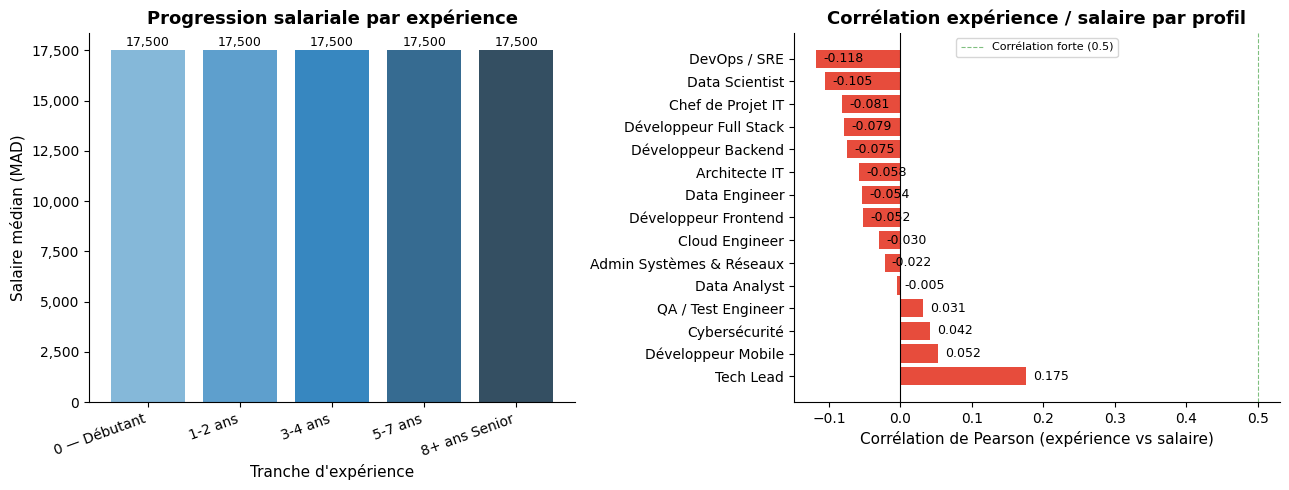

Figure sauvegardée : correlation_experience_salaire.png


In [13]:
# ── Salaire médian par tranche (toutes offres) ────────────────
df_exp_agg = con.execute(f"""
    SELECT
        CASE
            WHEN experience_min_ans = 0            THEN '0 — Débutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8            THEN '8+ ans Senior'
        END AS tranche,
        COUNT(*)                                                  AS nb_offres,
        ROUND(MEDIAN(salaire_median_mad) FILTER (WHERE salaire_connu), 0) AS salaire_median
    FROM read_parquet('{SILVER_OFF}')
    WHERE experience_min_ans IS NOT NULL
    GROUP BY tranche
    ORDER BY MIN(experience_min_ans)
""").df()

# ── Visualisation 4 : Progression salaire / expérience ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gauche : bar chart par tranche
ax = axes[0]
bars = ax.bar(df_exp_agg['tranche'], df_exp_agg['salaire_median'],
              color=sns.color_palette('Blues_d', len(df_exp_agg)))
ax.set_xlabel('Tranche d\'expérience')
ax.set_ylabel('Salaire médian (MAD)')
ax.set_title('Progression salariale par expérience', fontweight='bold')
ax.set_xticklabels(df_exp_agg['tranche'], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha='center', fontsize=9)

# Droite : corrélation Pearson par profil
ax2 = axes[1]
colors_corr = ['#2ecc71' if v > 0.5 else '#e67e22' if v > 0.3 else '#e74c3c'
               for v in df_corr['correlation_pearson']]
ax2.barh(df_corr['profil'], df_corr['correlation_pearson'], color=colors_corr)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(0.5, color='green', linewidth=0.8, linestyle='--', alpha=0.5, label='Corrélation forte (0.5)')
ax2.set_xlabel('Corrélation de Pearson (expérience vs salaire)')
ax2.set_title('Corrélation expérience / salaire par profil', fontweight='bold')
ax2.legend(fontsize=8)
for i, (_, row) in enumerate(df_corr.iterrows()):
    ax2.text(row['correlation_pearson'] + 0.01, i,
             f"{row['correlation_pearson']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('correlation_experience_salaire.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : correlation_experience_salaire.png')

### Interprétation — Question 4

Les résultats révèlent une conclusion surprenante et stratégiquement importante :
**l'expérience requise ne prédit pratiquement pas le salaire proposé** sur le marché
IT marocain. Les corrélations de Pearson sont toutes proches de zéro, voire légèrement
négatives pour la majorité des profils.

Le profil avec la corrélation la plus forte est **Tech Lead** (r = 0,175), ce qui reste
une relation très faible. Pour tous les profils Data, les corrélations sont négligeables
voire légèrement négatives : Data Analyst (r = -0,005), Data Engineer (r = -0,054),
Data Scientist (r = -0,105). **DevOps/SRE** présente la corrélation la plus négative
(r = -0,118).

Ces résultats s'expliquent par plusieurs facteurs propres au marché marocain :
- Les entreprises calibrent les salaires davantage sur le **profil de compétences
  techniques** (stack maîtrisée) que sur les années d'expérience déclarées.
- La coexistence d'offres de stage et de postes seniors dans les mêmes catégories de
  profils "bruite" la relation expérience/salaire.
- Les fourchettes salariales publiées sont souvent des plages larges peu corrélées
  au niveau d'expérience précis demandé.

**Recommandation pour Mexora** : ne pas définir les grilles salariales uniquement sur
la base des années d'expérience. Privilégier une évaluation technique des compétences
concrètes (Docker, SQL, cloud) comme critère de rémunération — c'est la logique que
le marché marocain a déjà adoptée.

---
## Question 5 — Quelles entreprises recrutent le plus ? Qui sont les concurrents de Mexora ?

**Approche** : top 20 recruteurs nationaux, puis focus sur les entreprises recrutant des profils Data à Tanger.

In [14]:
# ── Top 20 entreprises recruteurs ────────────────────────────
df_top_ent = con.execute(f"""
    SELECT
        entreprise,
        ville,
        nb_offres_publiees,
        nb_profils_differents,
        salaire_moyen_propose,
        RANK() OVER (ORDER BY nb_offres_publiees DESC) AS rang_recruteur
    FROM read_parquet('{ENTREPRISES}')
    ORDER BY nb_offres_publiees DESC
    LIMIT 20
""").df()

df_top_ent

,entreprise,ville,nb_offres_publiees,nb_profils_differents,salaire_moyen_propose,rang_recruteur
0,Sofrecom Maroc,Casablanca,34,12,21342.0,1
1,BMCE Bank,Casablanca,33,12,27333.0,2
2,Attijariwafa Bank,Casablanca,30,13,24265.0,3
3,OCP Group,Casablanca,30,11,21944.0,3
4,RetailTech,Tanger,30,12,20312.0,3
5,InsurTech Solutions,Casablanca,29,14,21973.0,6
6,Keyrus Maroc,Casablanca,28,10,18018.0,7
7,EduTech Maroc,Casablanca,28,12,19587.0,7
8,HPS Software,Casablanca,27,10,18796.0,9
9,DigitalHub Maroc,Tanger,27,10,26045.0,9


In [15]:
# ── Concurrents directs Mexora : Data à Tanger ───────────────
df_concurrents = con.execute(f"""
    SELECT
        entreprise,
        nb_offres_publiees,
        profils_recrutes,
        salaire_moyen_propose,
        CASE
            WHEN salaire_moyen_propose > 20000 THEN 'Compétiteur fort'
            WHEN salaire_moyen_propose > 12000 THEN 'Compétiteur moyen'
            ELSE 'Compétiteur faible'
        END AS niveau_competition
    FROM read_parquet('{ENTREPRISES}')
    WHERE ville = 'Tanger'
      AND (
          array_contains(profils_recrutes, 'Data Engineer')
       OR array_contains(profils_recrutes, 'Data Analyst')
      )
    ORDER BY salaire_moyen_propose DESC NULLS LAST
""").df()

df_concurrents

,entreprise,nb_offres_publiees,profils_recrutes,salaire_moyen_propose,niveau_competition
0,Startup Digital,19,"[Autre IT, Chef de Projet IT, Cybersécurité, D...",26481.0,Compétiteur fort
1,DigitalHub Maroc,27,"[Admin Systèmes & Réseaux, Architecte IT, Autr...",26045.0,Compétiteur fort
2,CyberSec Maroc,19,"[Architecte IT, Autre IT, Chef de Projet IT, C...",25708.0,Compétiteur fort
3,AI Solutions Maroc,25,"[Architecte IT, Autre IT, Chef de Projet IT, C...",25680.0,Compétiteur fort
4,DataFlow Systems,23,"[Admin Systèmes & Réseaux, Architecte IT, Autr...",24379.0,Compétiteur fort
5,Mexora,22,"[Admin Systèmes & Réseaux, Architecte IT, Autr...",24289.0,Compétiteur fort
6,OCP Group,26,"[Autre IT, Chef de Projet IT, Cybersécurité, D...",23541.0,Compétiteur fort
7,HPS Software,19,"[Autre IT, Chef de Projet IT, Cybersécurité, D...",23325.0,Compétiteur fort
8,FinTech Maroc,19,"[Architecte IT, Autre IT, Cybersécurité, Data ...",23194.0,Compétiteur fort
9,InsurTech Solutions,20,"[Architecte IT, Autre IT, Cybersécurité, Data ...",23043.0,Compétiteur fort


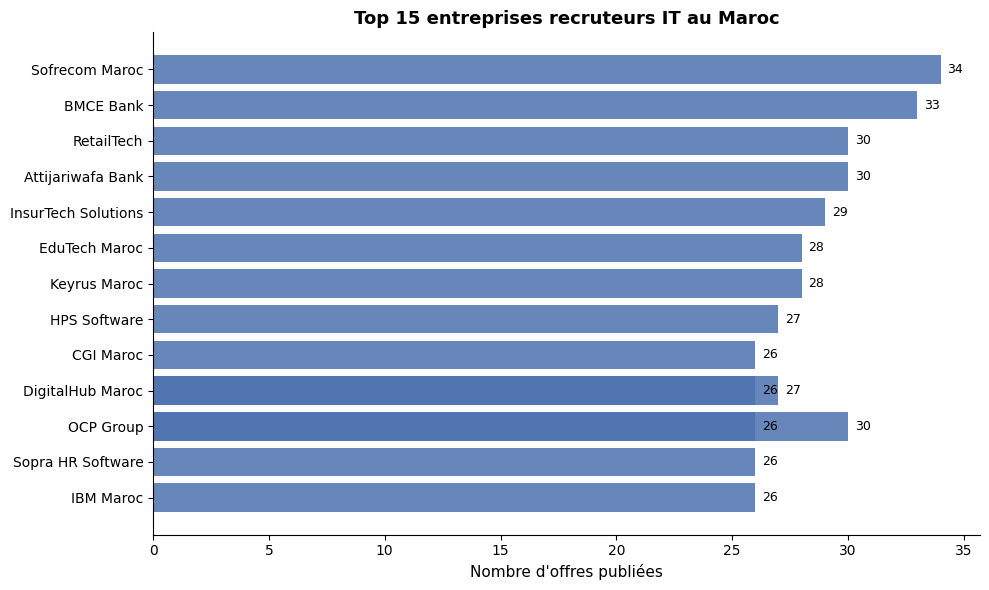

Figure sauvegardée : top15_recruteurs.png


In [16]:
# ── Visualisation 5 : Top 15 recruteurs (bar chart) ──────────
df_plot_ent = df_top_ent.head(15).sort_values('nb_offres_publiees')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    df_plot_ent['entreprise'],
    df_plot_ent['nb_offres_publiees'],
    color='#4C72B0', alpha=0.85
)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)

ax.set_xlabel('Nombre d\'offres publiées')
ax.set_title('Top 15 entreprises recruteurs IT au Maroc', fontweight='bold')
plt.tight_layout()
plt.savefig('top15_recruteurs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : top15_recruteurs.png')

### Interpr?tation ? Question 5

Le march? IT marocain est anim? par un mix d'acteurs ?tablis et de structures plus
r?centes. **Sofrecom Maroc** domine le classement national avec 34 offres publi?es,
suivi de **BMCE Bank** (33, salaire moyen 27 333 MAD ? le plus ?lev? du top 20) et
d'un trio ? 30 offres : **OCP Group**, **Attijariwafa Bank** et **RetailTech** (Tanger).
Les banques (BMCE, Attijariwafa, Wafasalaf) et les grands groupes industriels (OCP)
ressortent comme les recruteurs IT les plus actifs et les mieux r?mun?rateurs.

**? Tanger sp?cifiquement**, **20 entreprises** recrutent des profils Data Engineer ou
Data Analyst. Mexora se retrouve dans un environnement comp?titif dense :
- **Startup Digital** (19 offres, 26 481 MAD), **DigitalHub Maroc** (27 offres,
  26 045 MAD) et **AI Solutions Maroc** (25 offres, 25 680 MAD) sont les concurrents
  les plus forts, proposant des salaires moyens sup?rieurs ? Mexora (24 289 MAD).
- **CyberSec Maroc** (19 offres, 25 708 MAD), **DataFlow Systems** (23 offres,
  24 379 MAD) et **OCP Group Tanger** (26 offres, 23 541 MAD) compl?tent le tableau
  des comp?titeurs forts.
- **Alten Maroc**, **IBM Maroc** et **Orange Business Services** se positionnent
  comme comp?titeurs moyens (12 000?20 000 MAD), offrant ? Mexora une fen?tre pour
  se diff?rencier vers le haut.

**Recommandation pour Mexora** : pour ne pas perdre de candidats face ? Startup Digital,
DigitalHub Maroc ou AI Solutions Maroc, aligner les offres Data sur une fourchette
**25 000?28 000 MAD** pour les profils confirm?s. Mettre en avant la diversit? des
missions (Mexora recrute sur 10+ profils diff?rents) et les perspectives d'?volution
comme leviers d'attraction non-salariaux.


---
## Dashboard de synthèse

Récapitulatif visuel en 4 graphiques : compétences, salaires, géographie, tendances mensuelles.

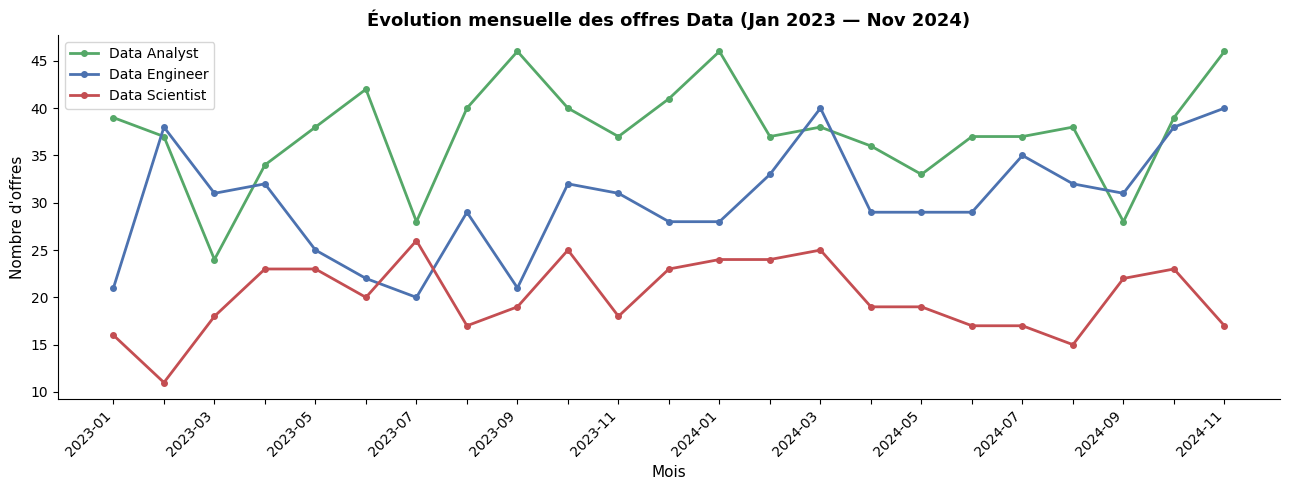

Figure sauvegardée : evolution_mensuelle.png


In [17]:
# ── Évolution mensuelle (Data Engineer / Analyst / Scientist) ─
df_evol = con.execute(f"""
    SELECT
        annee || '-' || mois AS periode,
        profil,
        nb_offres
    FROM read_parquet('{TENDANCES}')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND annee IS NOT NULL AND mois IS NOT NULL
    ORDER BY annee, mois
""").df()

fig, ax = plt.subplots(figsize=(13, 5))
palette_evol = {'Data Engineer': '#4C72B0', 'Data Analyst': '#55A868', 'Data Scientist': '#C44E52'}

for profil, groupe in df_evol.groupby('profil'):
    ax.plot(groupe['periode'], groupe['nb_offres'],
            label=profil, color=palette_evol[profil], linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Mois')
ax.set_ylabel('Nombre d\'offres')
ax.set_title('Évolution mensuelle des offres Data (Jan 2023 — Nov 2024)', fontweight='bold')
ax.legend()
# Afficher 1 label sur 2 pour lisibilité
labels = ax.get_xticklabels()
for i, label in enumerate(labels):
    if i % 2 != 0:
        label.set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : evolution_mensuelle.png')

In [18]:
# ?? R?capitulatif des 5 chiffres cl?s ????????????????????????
print('=' * 55)
print('  MEXORA RH INTELLIGENCE ? Chiffres cl?s')
print('=' * 55)

total = con.execute(f"SELECT COUNT(*) FROM read_parquet('{SILVER_OFF}')").fetchone()[0]
nb_comp = con.execute(f"""
    SELECT COUNT(DISTINCT competence) FROM read_parquet('{TOP_COMP}')
    WHERE competence != 'non_d?tect?'
""").fetchone()[0]
sal_med = con.execute(f"""
    SELECT MEDIAN(salaire_median_mad) FROM read_parquet('{SILVER_OFF}')
    WHERE salaire_connu = true
""").fetchone()[0]
top_skill = con.execute(f"""
    SELECT competence
    FROM read_parquet('{TOP_COMP}')
    WHERE competence != 'non_d?tect?'
    GROUP BY competence
    ORDER BY SUM(nb_offres_mentionnent) DESC
    LIMIT 1
""").fetchone()[0]
top_ville = con.execute(f"""
    SELECT ville FROM read_parquet('{VILLES}')
    GROUP BY ville ORDER BY SUM(nb_offres) DESC LIMIT 1
""").fetchone()[0]

print(f'  Offres analys?es          : {total:,}')
print(f'  Comp?tences uniques       : {nb_comp}')
print(f'  Salaire m?dian IT (MAD)   : {int(sal_med):,}')
print(f'  Comp?tence n?1            : {top_skill}')
print(f'  Ville la plus active      : {top_ville}')
print('=' * 55)


  MEXORA RH INTELLIGENCE ? Chiffres cl?s
  Offres analys?es          : 5,000
  Comp?tences uniques       : 70
  Salaire m?dian IT (MAD)   : 17,500
  Comp?tence n?1            : docker
  Ville la plus active      : Casablanca
